In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


df.head()

In [11]:
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese"]

df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=bmi_bins,
    labels=bmi_labels
)

df[["BMI", "BMI_Category"]].head()

,BMI,BMI_Category
0,33.6,Obese
1,26.6,Overweight
2,23.3,Normal
3,28.1,Overweight
4,43.1,Obese


In [12]:
age_bins = [0, 30, 45, 60, 100]
age_labels = ["Young", "Middle-Aged", "Senior", "Elderly"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

df[["Age", "Age_Group"]].head()

,Age,Age_Group
0,50,Senior
1,31,Middle-Aged
2,32,Middle-Aged
3,21,Young
4,33,Middle-Aged


In [13]:
df["Glucose_Insulin_Ratio"] = (
    df["Glucose"] / (df["Insulin"] + 1)
)

df[["Glucose", "Insulin", "Glucose_Insulin_Ratio"]].head()

,Glucose,Insulin,Glucose_Insulin_Ratio
0,148,0,148.000000
1,85,0,85.000000
2,183,0,183.000000
3,89,94,0.936842
4,137,168,0.810651


In [14]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Insulin_Ratio
0,6,148,72,35,0,33.6,0.627,50,1,Obese,Senior,148.000000
1,1,85,66,29,0,26.6,0.351,31,0,Overweight,Middle-Aged,85.000000
2,8,183,64,0,0,23.3,0.672,32,1,Normal,Middle-Aged,183.000000
3,1,89,66,23,94,28.1,0.167,21,0,Overweight,Young,0.936842
4,0,137,40,35,168,43.1,2.288,33,1,Obese,Middle-Aged,0.810651


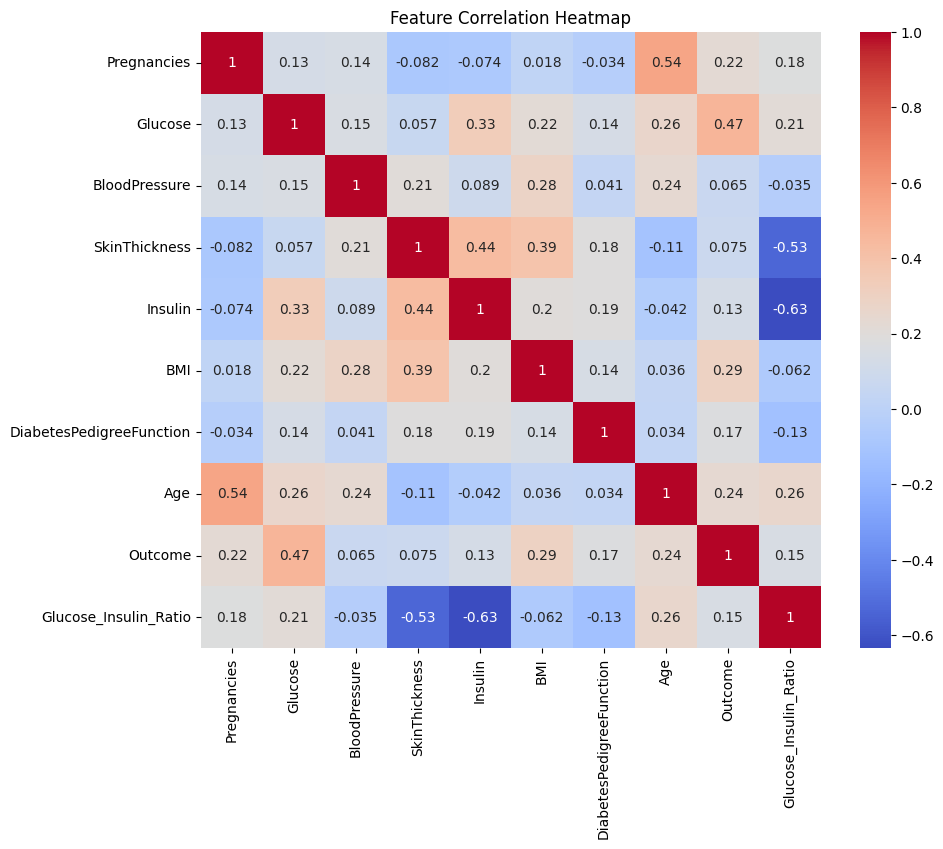

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

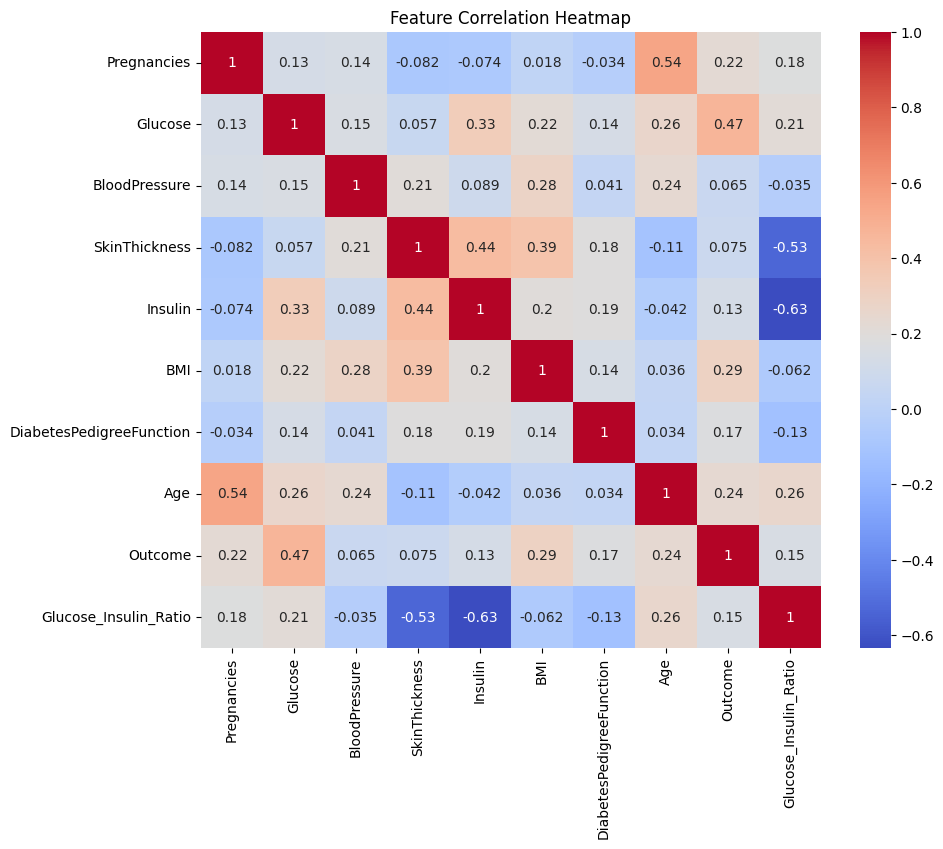

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("../results", exist_ok=True)

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.savefig(
    "../results/feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()